In [2]:
from Objects.WSBM import *

In [121]:
A, Z = betaWSBM(0.1, 0.3, (0.9, 0.1), n = 100)(seed=40)

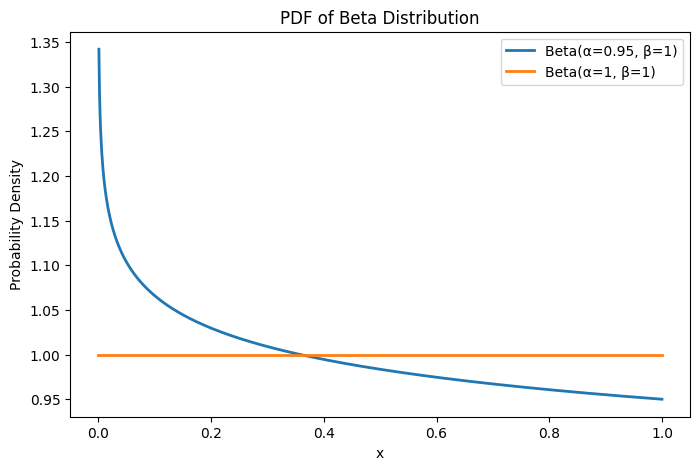

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta


x = np.linspace(0, 1, 1000)

# Calculate the pdf for each x value
a1 = 0.95
a2 = 1
b = 1

plt.figure(figsize=(8, 5))
plt.plot(x, beta.pdf(x, a1, 1), label=f'Beta(α={a1}, β={b})', lw=2)
plt.plot(x, beta.pdf(x, a2, 1), label=f'Beta(α={a2}, β={b})', lw=2)
plt.title('PDF of Beta Distribution')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

colors = {0: "blue", 1: "red", (0, 0) : "blue", (1, 1) : "red", (0, 1) : "gray", (1, 0) : "gray"}

G = nx.from_numpy_array(A)
edge_colors  = [colors[(Z[u], Z[v])] for u, v in G.edges() ]
G0 = [n for n in G.nodes() if Z[n] == 0]
G1 = [n for n in G.nodes() if Z[n] == 1]
E0 = [e for e in G.edges() if Z[e[0]] == 0 and Z[e[1]] == 0]
E1 = [e for e in G.edges() if Z[e[0]] == 1 and Z[e[1]] == 1]
E01 = [e for e in G.edges() if Z[e[0]] != Z[e[1]]]
W0 = np.array([G[u][v]['weight'] for u, v in E0])
W1 = np.array([G[u][v]['weight'] for u, v in E1])
W01 = np.array([G[u][v]['weight'] for u, v in E01])


superG = nx.cycle_graph(2)
superpos = nx.spring_layout(superG, scale=0.4, seed=42)

pos = {}
seed_val = 1430
pos.update(nx.spring_layout(G.subgraph(G0), center=superpos[0], seed=seed_val, scale=1))
pos.update(nx.spring_layout(G.subgraph(G1), center=superpos[1], seed=seed_val, scale=0.6))

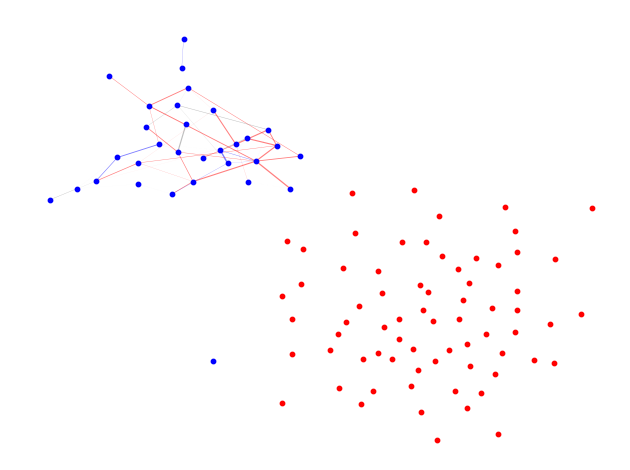

In [133]:
nx.draw_networkx_nodes(G, pos, nodelist=G0, node_color=colors[0], node_size=10, alpha=1)
nx.draw_networkx_nodes(G, pos, nodelist=G1, node_color=colors[1], node_size=10, alpha=1)
nx.draw_networkx_edges(G, pos, edgelist=E0, edge_color=edge_colors, width=edge_weights, alpha=0.5)

plt.tight_layout()
plt.axis('off')
plt.show()